In [1]:
!pwd

/home/cellatlas/biol-paper/GBP_2024/notebooks


In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import seaborn as sns
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import anndata
from ec.utils import read_markers_txt
from collections import defaultdict
from sklearn.neighbors import kneighbors_graph
import random
from scipy.stats import zscore

def nd(arr):
    return np.asarray(arr).reshape(-1)

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [50]:
sns.set_context('poster')

## Read marker expression

In [29]:
marker_expression_df = pd.read_csv('../files/testis_markers_log1pPF_gex.tsv.gz', sep = '\t',
           index_col = 0)

## Read markers.txt file

In [53]:

# Read markers.txt
markers_dict = defaultdict(list)
read_markers_txt('../files/testis_markers.other.txt', markers_dict)

    
celltypes = list(markers_dict.keys())    
celltypes_no_other = list(markers_dict.keys())
celltypes_no_other.remove('Other') 

## Calculate average expression by cell-type

In [54]:
ct_names_dict = {"RoundSpermatid": "Round Spermatid",
 "Elongating": "Elongating Spermatid",
 "f-Pericyte": "Fibroblastic Pericyte",
 "m-Pericyte": "Muscular Pericyte",
 "Tcell" :"T-cell",
 "ImmLeydig": "Immature Leydig", 'other': 'Other',
 # these cell types remain the same
 'Macrophage': 'Macrophage', 'Endothelial':'Endothelial',
 'Myoid': 'Myoid', 'Spermatogonia': 'Spermatogonia',
 'Spermatocyte': 'Spermatocyte', 'Other': 'Other', }

order = ["Macrophage","Endothelial", "Immature Leydig", "T-cell", "Myoid",
         "Muscular Pericyte",
        "Spermatogonia",  "Spermatocyte", "Round Spermatid",
         "Elongating Spermatid"]

order_old = ["Macrophage","Endothelial", "ImmLeydig", "Tcell", "Myoid",
         "m-Pericyte",
        "Spermatogonia",  "Spermatocyte", "RoundSpermatid",
         "Elongating"]

In [55]:
grouped_marker_expression_df = marker_expression_df.groupby('label').mean().iloc[:,2:]
grouped_marker_expression_df = grouped_marker_expression_df.loc[order_old]

In [56]:
ordered_markers = []
for ct in grouped_marker_expression_df.index:
    ordered_markers.extend(markers_dict[ct])

## Calculate z-score across cells

In [57]:
zscore_genes = zscore(grouped_marker_expression_df, axis =0)
zscore_df = pd.DataFrame(zscore_genes)
zscore_df.columns = grouped_marker_expression_df.columns
zscore_df.index = grouped_marker_expression_df.index
zscore_df = zscore_df.reindex(order_old)
zscore_df.index = [ct_names_dict[c] for c in zscore_df.index]

In [58]:
zscore_df = zscore_df.T.reindex(ordered_markers).T

## Plot

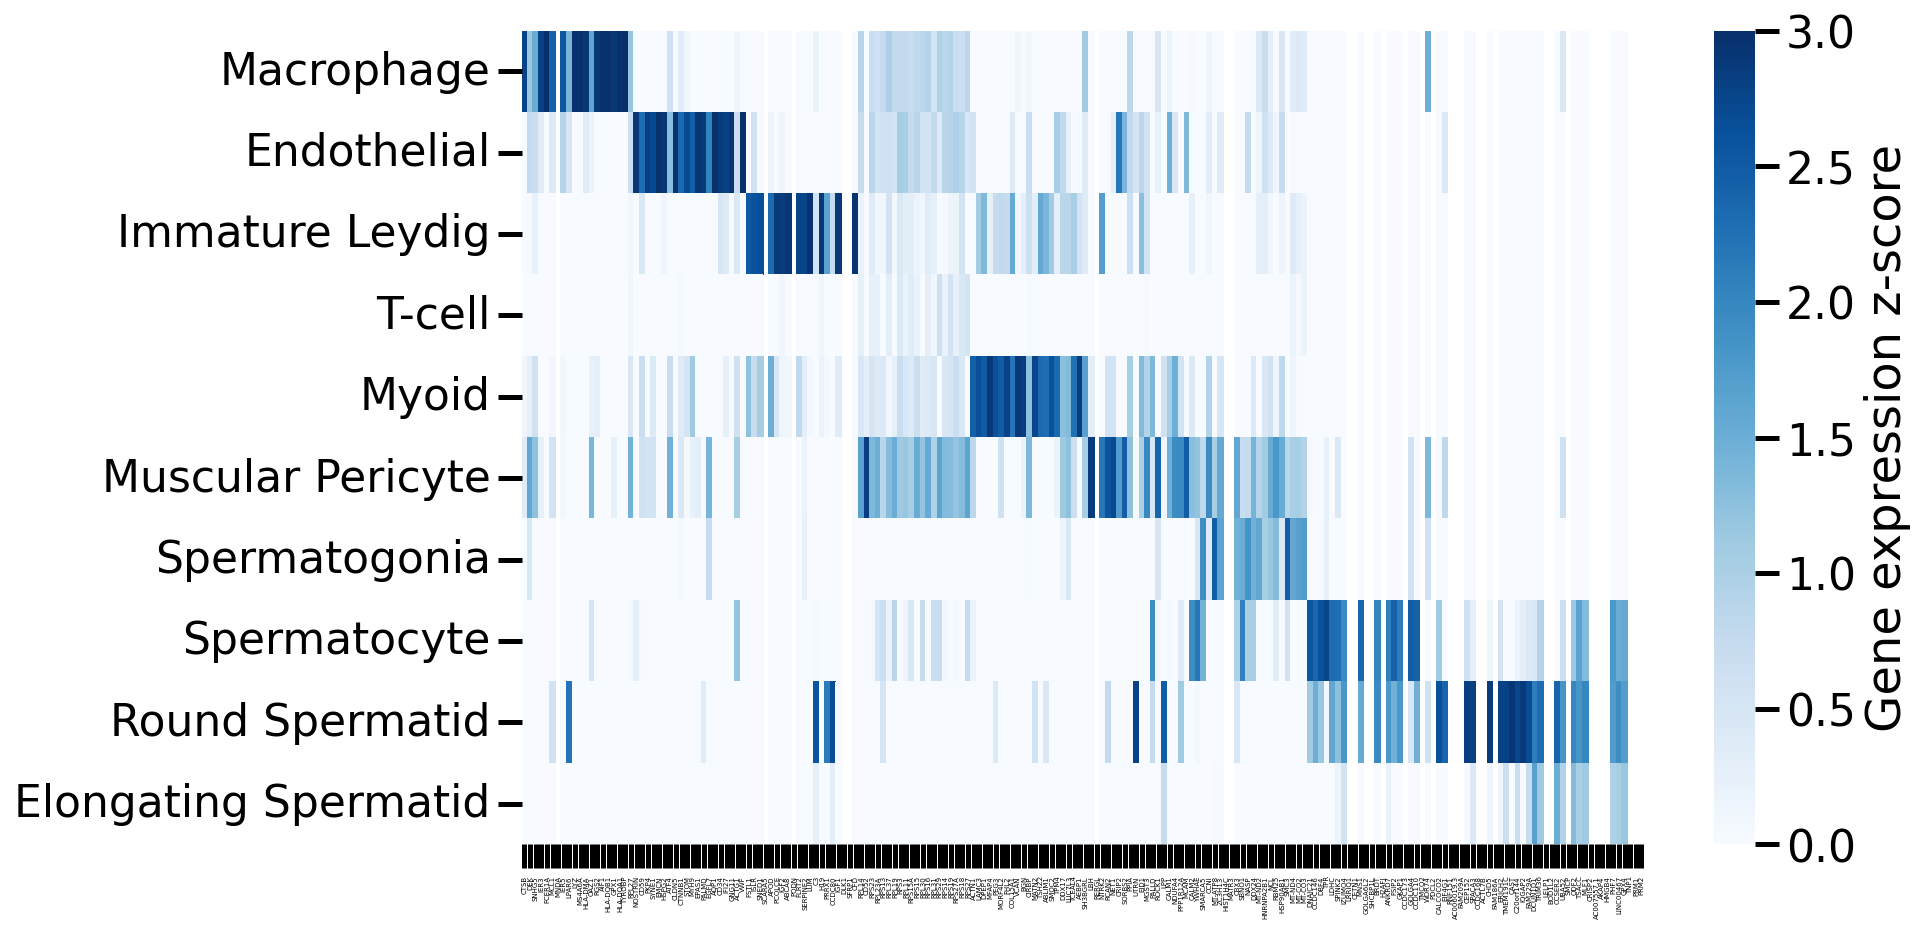

In [51]:
fig, ax = plt.subplots(figsize = (14,7))
sns.heatmap(zscore_df, cmap = 'Blues', 
            vmin = 0, vmax = 3, center = 1.5, xticklabels=zscore_df.columns, ax=ax, cbar_kws={'label': 'Gene expression z-score'})

ax.tick_params(axis='x', rotation=90, labelsize = 3.5)

ax.set_ylabel('')
plt.tight_layout()
plt.savefig('figures/fig_1d.png')